# Visium Spatial Gallery

Spatial plots colored by Leiden clustering for all models (topomics variants + baselines).

Found 11 topomics model runs
=== sctm_comparison/prior_horseshoe ===


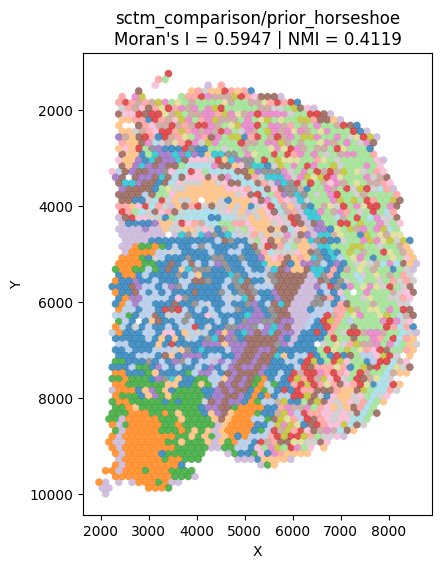

=== sctm_comparison/prior_logistic_normal ===


/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


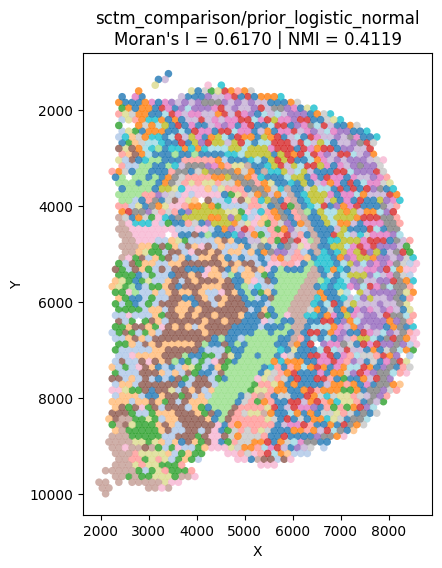

=== sctm_comparison/prior_logistic_normal_gcn2 ===


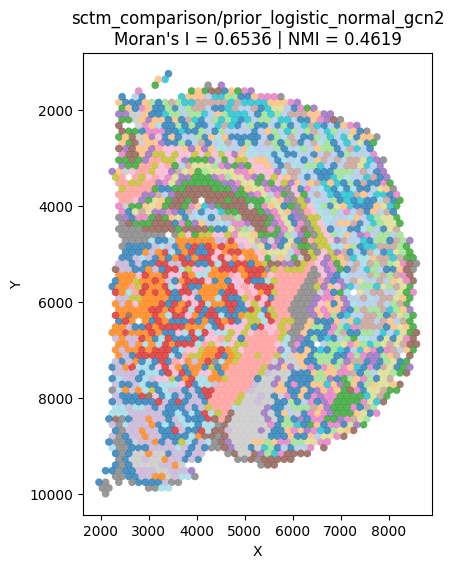

=== sctm_comparison/prior_logistic_normal_gcn2_learnable_disp_global ===


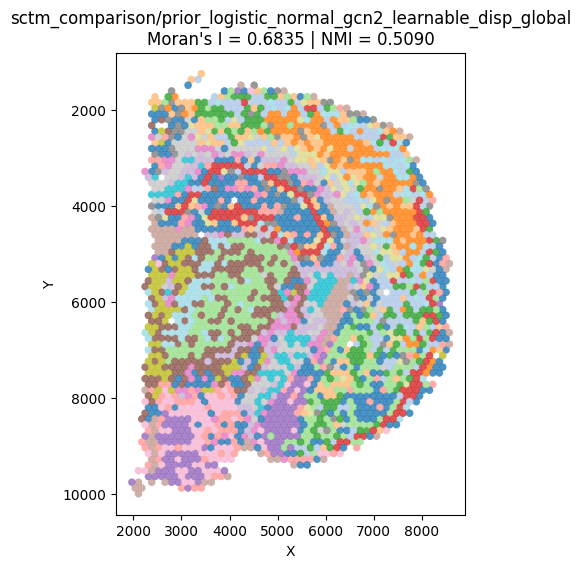

=== sctm_comparison/prior_logistic_normal_gcn2_learnable_disp_pergene ===


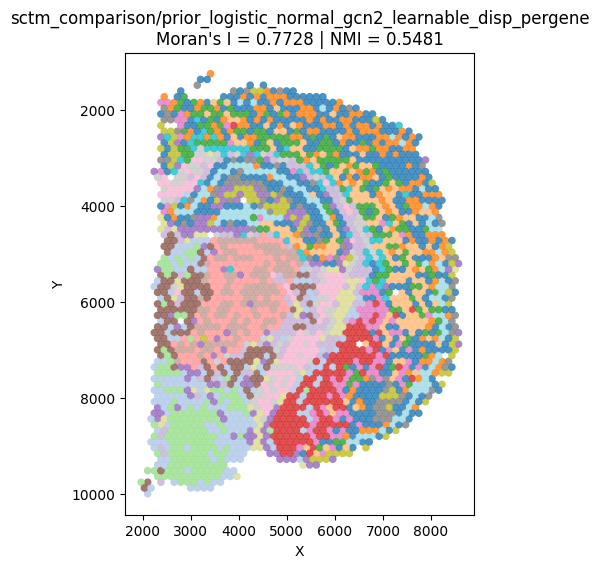

=== sctm_comparison/prior_logistic_normal_learnable_disp_global ===


/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


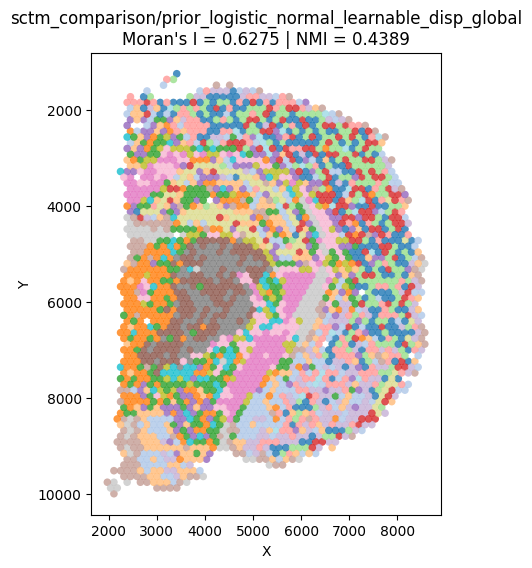

=== sctm_comparison/prior_logistic_normal_learnable_disp_pergene ===


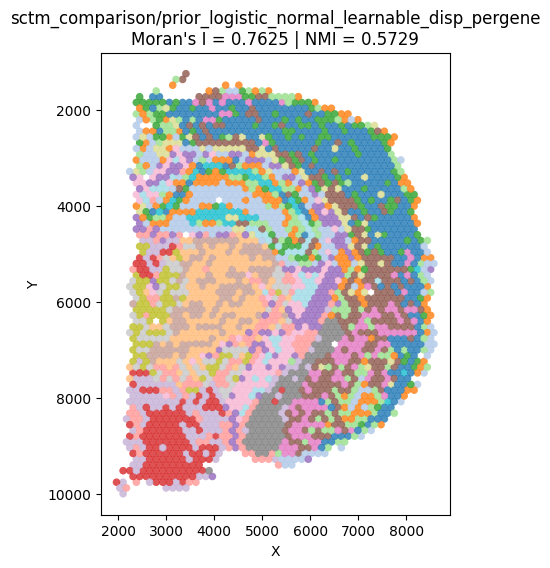

=== sctm_comparison_graphconv/prior_logistic_normal ===


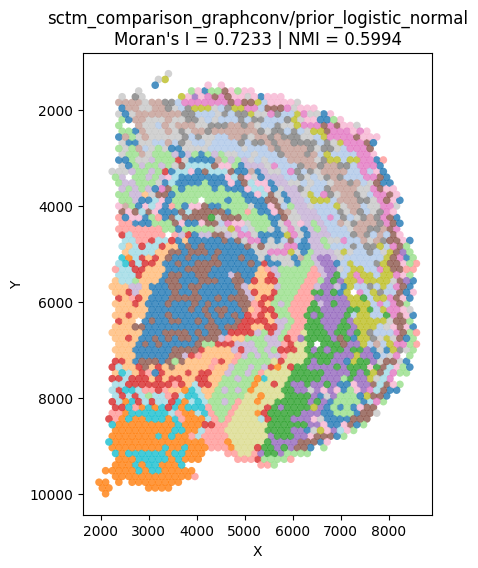

=== sctm_comparison_graphconv/prior_logistic_normal_gcn2 ===


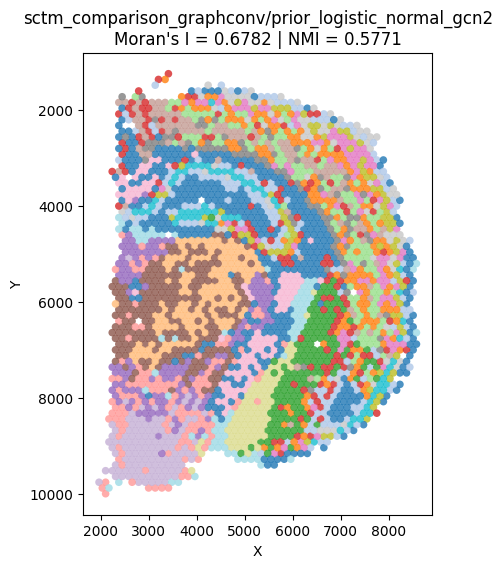

=== sctm_comparison_meanfield/prior_horseshoe ===


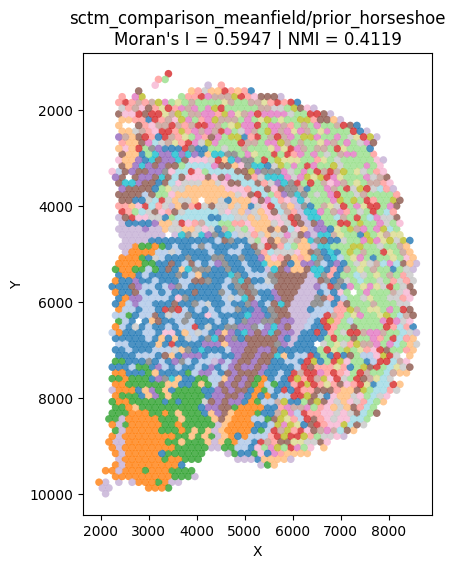

=== sctm_comparison_meanfield/prior_logistic_normal ===


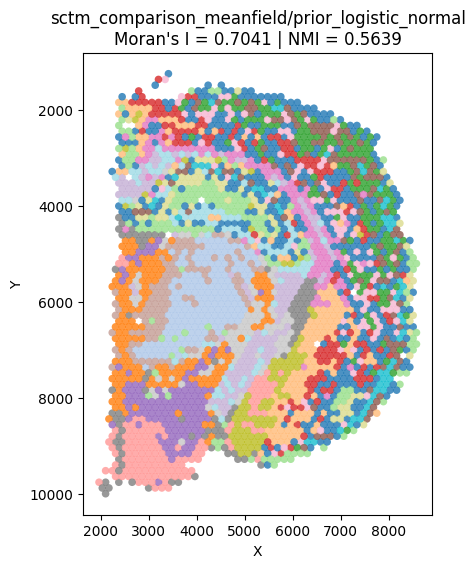


Baseline models
=== scVI ===


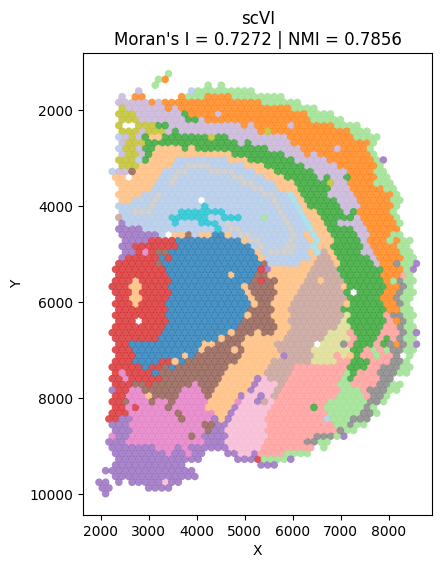

=== STAMP ===


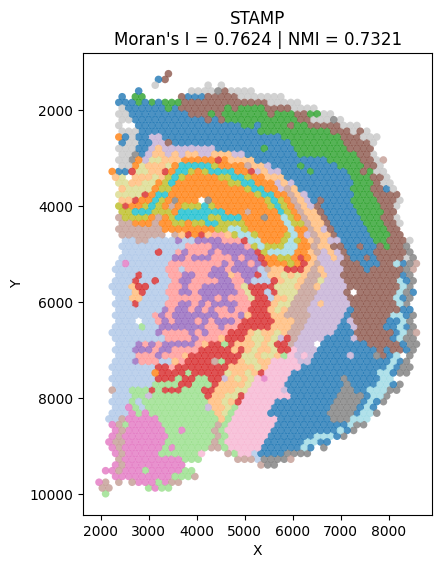

=== AmortizedLDA ===


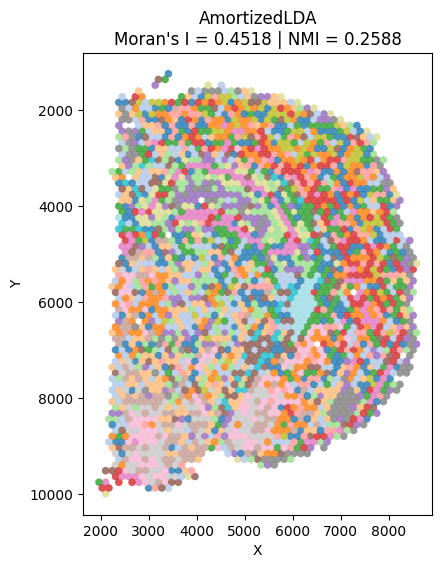

In [13]:
from pathlib import Path
import numpy as np
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score


def compute_moran_i(values, spatial_weights):
    n = len(values)
    z = values - values.mean()
    W = spatial_weights.tocsr()
    numerator = z @ W @ z
    denominator = z @ z
    if denominator == 0:
        return 0.0
    S0 = W.sum()
    if S0 == 0:
        return 0.0
    return (n / S0) * (numerator / denominator)


def plot_spatial_leiden(theta, spatial_coords, spatial_weights, adata, title):
    morans_values = [compute_moran_i(theta[:, i], spatial_weights) for i in range(theta.shape[1])]
    mean_morans = np.mean(morans_values)

    adata.obsm["X_topic"] = theta - 1
    sc.pp.neighbors(adata, metric="cosine", use_rep="X_topic", key_added="topic_neighbors")
    sc.tl.leiden(adata, neighbors_key="topic_neighbors", key_added="leiden")

    nmi = normalized_mutual_info_score(
        adata.obs["cluster"].astype(str),
        adata.obs["leiden"].astype(str),
        average_method="arithmetic",
    )

    leiden_encoded = adata.obs["leiden"].astype("category").cat.codes.to_numpy()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(
        spatial_coords[:, 0],
        spatial_coords[:, 1],
        c=leiden_encoded,
        cmap="tab20",
        s=30,
        alpha=0.8,
        linewidths=0,
    )
    ax.set_title(f"{title}\nMoran's I = {mean_morans:.4f} | NMI = {nmi:.4f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    plt.show()
    return {"morans_i": mean_morans, "nmi": nmi}


# ---- Load Visium dataset (same as training) ----
adata = sq.datasets.visium_hne_adata()
adata.X = adata.raw.X
if "spatial_connectivities" not in adata.obsp:
    sq.gr.spatial_neighbors(adata, coord_type="generic")

spatial_coords = adata.obsm["spatial"]
spatial_weights = adata.obsp["spatial_connectivities"]

# ---- TopOmics models ----
base_dirs = [
    Path("/data/topomics_models/sctm_comparison"),
    Path("/data/topomics_models/sctm_comparison_graphconv"),
    Path("/data/topomics_models/sctm_comparison_meanfield"),
]

run_dirs = []
for base in base_dirs:
    if not base.exists():
        print(f"Warning: {base} does not exist")
        continue
    for d in sorted(base.iterdir()):
        if d.is_dir() and d.name.startswith("prior_"):
            latent_path = d / "latent_representation.npy"
            if latent_path.exists():
                run_dirs.append(d)

print(f"Found {len(run_dirs)} topomics model runs")

all_metrics = {}
for run_dir in run_dirs:
    display_name = f"{run_dir.parent.name}/{run_dir.name}"
    print(f"=== {display_name} ===")
    theta = np.load(run_dir / "latent_representation.npy")
    all_metrics[display_name] = plot_spatial_leiden(theta, spatial_coords, spatial_weights, adata, display_name)

# ---- Baseline models ----
BASELINES_DIR = Path("/data/topomics_models/sctm_comparison/baselines")
baseline_files = {
    "scVI": "latent_scvi.npy",
    "STAMP": "latent_stamp.npy",
    "AmortizedLDA": "latent_amortized_lda.npy",
}

print(f"\n{'='*60}")
print("Baseline models")
print(f"{'='*60}")

for name, fname in baseline_files.items():
    latent_path = BASELINES_DIR / fname
    if not latent_path.exists():
        print(f"  {name}: not found ({latent_path})")
        continue
    print(f"=== {name} ===")
    theta = np.load(latent_path)
    all_metrics[name] = plot_spatial_leiden(theta, spatial_coords, spatial_weights, adata, name)

/tmp/ipykernel_153409/4294717672.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="cluster", spot_size=100, title="Ground-truth annotation")


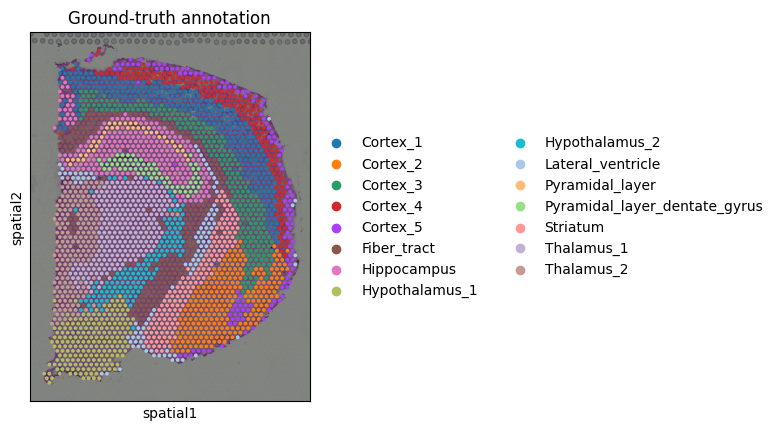

In [20]:
# Ground-truth annotation reference plot
sc.pl.spatial(adata, color="cluster", spot_size=100, title="Ground-truth annotation")

In [15]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'spatial_neighbors', 'topic_neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_topic'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'topic_neighbors_di

=== Summary: all models ranked by NMI ===


,Moran's I,NMI
scVI,0.7272,0.7856
STAMP,0.7624,0.7321
sctm_comparison_graphconv/prior_logistic_normal,0.7233,0.5994
sctm_comparison_graphconv/prior_logistic_normal_gcn2,0.6782,0.5771
sctm_comparison/prior_logistic_normal_learnable_disp_pergene,0.7625,0.5729
sctm_comparison_meanfield/prior_logistic_normal,0.7041,0.5639
sctm_comparison/prior_logistic_normal_gcn2_learnable_disp_pergene,0.7728,0.5481
sctm_comparison/prior_logistic_normal_gcn2_learnable_disp_global,0.6835,0.5090
sctm_comparison/prior_logistic_normal_gcn2,0.6536,0.4619
sctm_comparison/prior_logistic_normal_learnable_disp_global,0.6275,0.4389


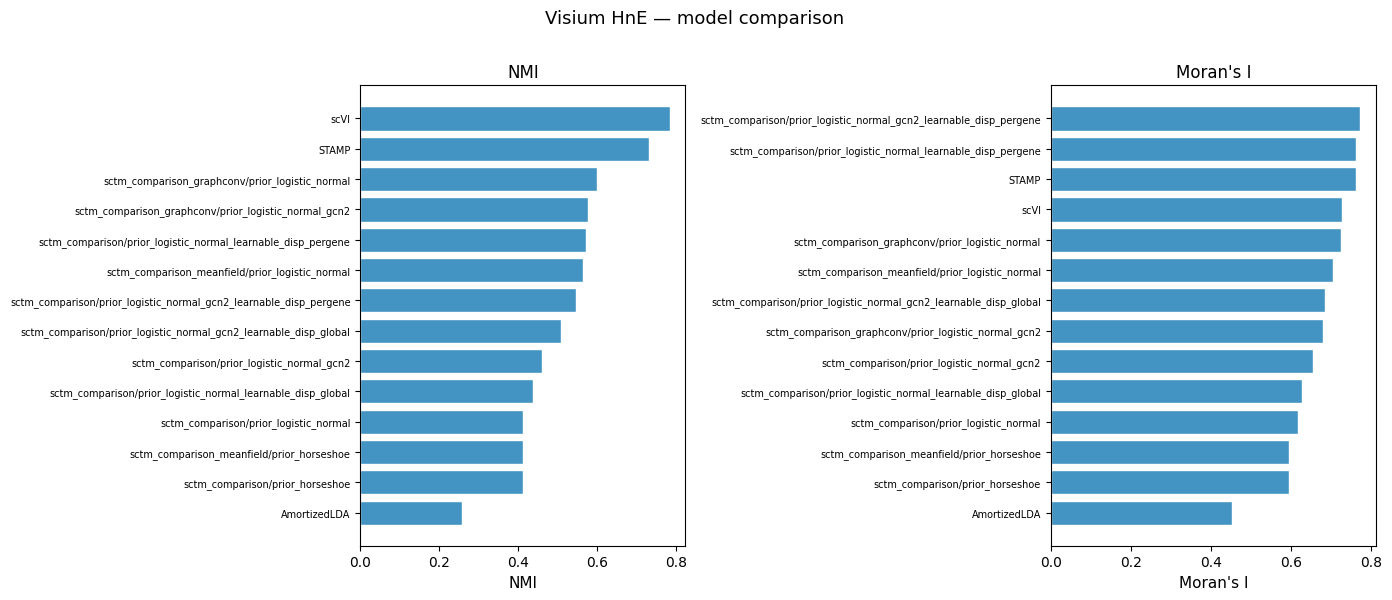

In [16]:
import pandas as pd

if all_metrics:
    df_metrics = (
        pd.DataFrame(all_metrics)
        .T
        .rename(columns={"morans_i": "Moran's I", "nmi": "NMI"})
        .sort_values("NMI", ascending=False)
    )
    print("=== Summary: all models ranked by NMI ===")
    display(df_metrics.style.format("{:.4f}").background_gradient(cmap="YlGn"))

    fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(df_metrics) * 0.35 + 1)))
    for ax, col in zip(axes, ["NMI", "Moran's I"]):
        df_plot = df_metrics[col].sort_values()
        ax.barh(df_plot.index, df_plot.values, color="#4393C3", edgecolor="white")
        ax.set_xlabel(col, fontsize=11)
        ax.set_title(col, fontsize=12)
        ax.tick_params(axis="y", labelsize=7)
    plt.suptitle("Visium HnE — model comparison", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()